<a href="https://colab.research.google.com/github/Rayhwcakep/machine_learning/blob/main/RayanaHanindra_TI3A_22_Kuis1_MachineLearning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Pengantar

Pada Kuis 1 ini Anda diminta untuk melakukan proses explorartory data analysis (EDA) dan pra pengolahan data pada dataset "Census Income". Dataset ini merupakan data tabular yang memiliki beberapa nilai yang hilang (missing value) dan nama variabel (fitur) yang perlu disesuaikan.

Untuk membantu Anda, notebook ini akan memberikan kode awal untuk proses download data, load data, dan inspeksi informasi terkait dengan metadata.

# Load Data and Inspect Metadata

In [3]:
# Install UCI REPO Library
!pip install -q ucimlrepo

In [4]:
# Import Required Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from ucimlrepo import fetch_ucirepo

In [5]:
# fetch data
adult_income = fetch_ucirepo(id=2)

In [14]:
# Data
X = adult_income.data.features
y = adult_income.data.targets

# Concate Features and Target
df = pd.concat([X, y], axis=1)

# Show Top 5
df.head()

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


In [9]:
# Data Size
df.shape

(48842, 15)

In [10]:
# Inspect metadata
adult_income.metadata

{'uci_id': 2,
 'name': 'Adult',
 'repository_url': 'https://archive.ics.uci.edu/dataset/2/adult',
 'data_url': 'https://archive.ics.uci.edu/static/public/2/data.csv',
 'abstract': 'Predict whether annual income of an individual exceeds $50K/yr based on census data. Also known as "Census Income" dataset. ',
 'area': 'Social Science',
 'tasks': ['Classification'],
 'characteristics': ['Multivariate'],
 'num_instances': 48842,
 'num_features': 14,
 'feature_types': ['Categorical', 'Integer'],
 'demographics': ['Age', 'Income', 'Education Level', 'Other', 'Race', 'Sex'],
 'target_col': ['income'],
 'index_col': None,
 'has_missing_values': 'yes',
 'missing_values_symbol': 'NaN',
 'year_of_dataset_creation': 1996,
 'last_updated': 'Tue Sep 24 2024',
 'dataset_doi': '10.24432/C5XW20',
 'creators': ['Barry Becker', 'Ronny Kohavi'],
 'intro_paper': None,
 'additional_info': {'summary': "Extraction was done by Barry Becker from the 1994 Census database.  A set of reasonably clean records was ex

# Bagian 1 - Data Loading dan Data Imputation

## Soal 1 (5 poin)
1.   Lakukan inspeksi profile data
2.   **Variabel apa** yang memiliki **nilai yang hilang** (missing value) dan **berapa** jumlahnya?



In [12]:
print(df.info())
print("\nDeskripsi Statistik Data:")
print(df.describe(include='all'))

# 2. Cek variabel dengan nilai hilang
df.replace('?', np.nan, inplace=True)

# Hitung jumlah missing value tiap kolom
missing_values = df.isnull().sum()
print("\nVariabel dengan missing value dan jumlahnya:")
print(missing_values[missing_values > 0])
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48842 entries, 0 to 48841
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             48842 non-null  int64 
 1   workclass       46043 non-null  object
 2   fnlwgt          48842 non-null  int64 
 3   education       48842 non-null  object
 4   education-num   48842 non-null  int64 
 5   marital-status  48842 non-null  object
 6   occupation      46033 non-null  object
 7   relationship    48842 non-null  object
 8   race            48842 non-null  object
 9   sex             48842 non-null  object
 10  capital-gain    48842 non-null  int64 
 11  capital-loss    48842 non-null  int64 
 12  hours-per-week  48842 non-null  int64 
 13  native-country  47985 non-null  object
 14  income          48842 non-null  object
dtypes: int64(6), object(9)
memory usage: 5.6+ MB
None

Deskripsi Statistik Data:
                 age workclass        fnlwgt education  educa

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


## Soal 2 (5 poin)
1. Lakukan proses data imputation pada fitur yang memiliki data yang hilang
2. Cek kembali apakah masih terdapat data yang hilang

In [17]:
# 1. Data imputation menggunakan modus untuk data kategorikal
for col in ['workclass', 'occupation', 'native-country']:
    if df[col].isnull().sum() > 0:
        modus_kolom = df[col].mode()[0]
        df[col].fillna(modus_kolom, inplace=True)

# 2. verifikasi missing value
print("Jumlah missing value setelah imputasi:\n", df.isnull().sum().sum())

Jumlah missing value setelah imputasi:
 0


/tmp/ipykernel_3972/2102086076.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(modus_kolom, inplace=True)


## Soal 3 (10 poin)
Inspeksi semua fitur kualitatif. Jika terdapat value yang **tidak sesuai**, **ganti dengan 'Others'** atau yang sesuai atau jika terdapat duplikasi karena **kesalahan penulisan**, lakukan penyesuaian.

In [18]:
# Memeriksa dan mengganti nilai kualitatif dengan proporsi sangat kecil menjadi 'Others'
df['native-country'] = df['native-country'].apply(lambda x: x if x == 'United-States' else 'Others')

status_map = {
    'Married-civ-spouse': 'Married',
    'Married-spouse-absent': 'Married',
    'Married-AF-spouse': 'Married',
    'Never-married': 'Single',
    'Divorced': 'Divorced',
    'Separated': 'Separated',
    'Widowed': 'Widowed'
}
df['marital-status'] = df['marital-status'].replace(status_map)

# Cek hasil
print(df['native-country'].value_counts())
print(df['marital-status'].value_counts())

native-country
United-States    44106
Others            4736
Name: count, dtype: int64
marital-status
Married      23044
Single       16117
Divorced      6633
Separated     1530
Widowed       1518
Name: count, dtype: int64


# Bagian 2 - Visual Inspection



## Soal 1 - Visualisasi Data (20 poin)
Lakukan inspeksi visual pada,
1. Pada kolom 'age' dengan menggunakan histrogram
2. Pada kolom 'education' education menggunakan barchart
3. Pada kolom 'income' terhadap 'hours_per_week' menggunakan boxplot (kelompokkan berdasarkan kelompok income)
4. Pada kolom 'age' terhadap 'capital-gain' dan 'capital-loss' dengan lineplot (1 lineplot 2 data)

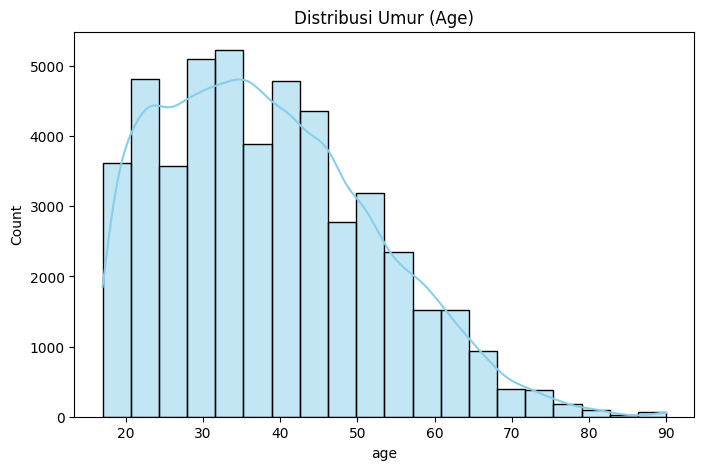

In [19]:
# Jawab 1.1 - Histogram (Kolom 'age')
plt.figure(figsize=(8,5))
sns.histplot(df['age'], bins=20, kde=True, color='skyblue')
plt.title('Distribusi Umur (Age)')
plt.show()

/tmp/ipykernel_3972/337478698.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=df['education'], order=df['education'].value_counts().index, palette='viridis')


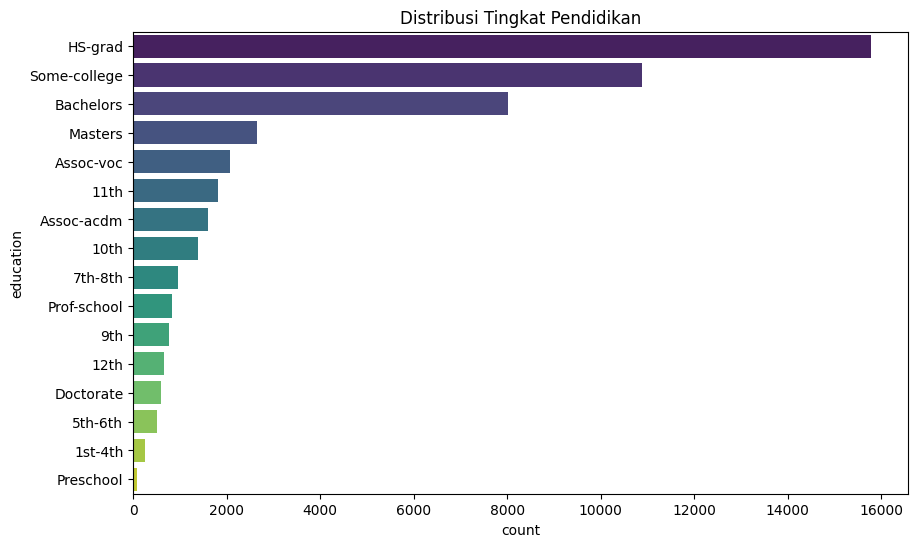

In [20]:
# Jawab 1.2 - Barchart (Kolom 'education')
plt.figure(figsize=(10,6))
sns.countplot(y=df['education'], order=df['education'].value_counts().index, palette='viridis')
plt.title('Distribusi Tingkat Pendidikan')
plt.show()

/tmp/ipykernel_3972/1775151316.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='income', y='hours-per-week', data=df, palette='Set2')


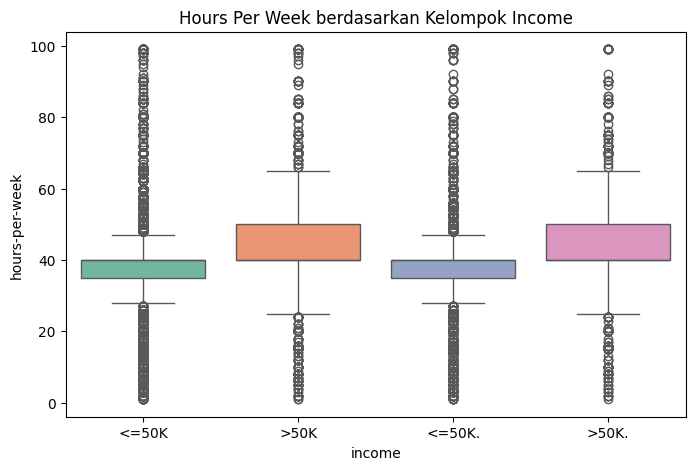

In [21]:
# Jawab 1.3 - Boxplot (Kolom 'income' terhadap 'hours-per-week')
plt.figure(figsize=(8,5))
sns.boxplot(x='income', y='hours-per-week', data=df, palette='Set2')
plt.title('Hours Per Week berdasarkan Kelompok Income')
plt.show()

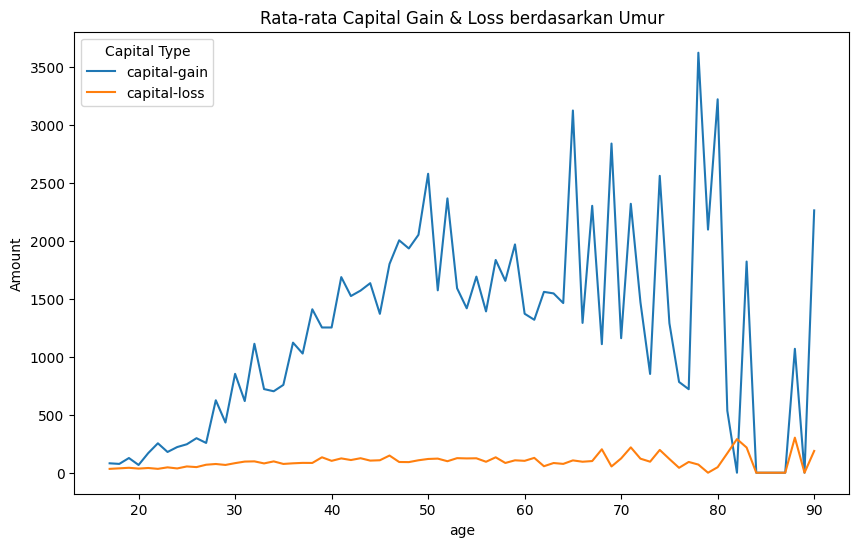

In [22]:
# Jawab 1.4 - Lineplot (Kolom 'age' terhadap 'capital-gain' dan 'capital-loss')
plt.figure(figsize=(10,6))
data_melted = pd.melt(df, id_vars=['age'], value_vars=['capital-gain', 'capital-loss'],
                      var_name='Capital Type', value_name='Amount')
sns.lineplot(x='age', y='Amount', hue='Capital Type', data=data_melted, errorbar=None)
plt.title('Rata-rata Capital Gain & Loss berdasarkan Umur')
plt.show()

## Soal 2 - Analisis Visual (15 poin)
1. Fenomena apa yang terjadi pada distribusi data 'age'?
2. Jika terdapat data yang hilang pada variabel 'age', strategi apa yang Anda terapkan? Mengapa?
3. Berapa jumlah outlier pada setiap kategori 'income' berkaitan dengan 'hour-per-week'? Kategori apa yang paling banyak memiliki outlier?

In [ ]:

'''
1. Fenomena apa yang terjadi pada distribusi data 'age'?
Jawaban: Distribusi data 'age' bersifat right-skewed (condong ke kanan) di mana sebagian besar data berada di rentang usia pekerja muda hingga paruh baya (20 - 50 tahun), dan terus menurun secara eksponensial di usia tua.

2. Jika terdapat data yang hilang pada variabel 'age', strategi apa yang diterapkan?
Jawaban: Strategi imputasi yang paling baik untuk data dengan distribusi right-skewed seperti 'age' adalah menggunakan nilai Median (Nilai Tengah) bukan Mean. Mean sangat sensitif terhadap nilai ekstrem/skewness sehingga bisa menghasilkan estimasi yang bias.

3. Outlier pada kategori 'income' berkaitan dengan 'hours-per-week':
Jawaban: Kelompok income '<=50K' memiliki sebaran outlier 'hours-per-week' terbanyak (terlihat banyak titik di luar whisker baik di atas jam kerja normal maupun jauh di bawahnya). Sedangkan kategori '>50K' juga memiliki outlier, tetapi lebih dominan pada jam kerja rendah.
'''

'\n  Bisa dengan multiple comment\n  seperti ini\n'

# Bagian 3 - Encoding Variabel Kategorical

## Soal 1 (5 poin)
Lakukan encoding pada 'Sex' dan 'Income'. 'Income' merupakan variabel target

In [23]:

# Menghapus titik pada kategori income jika ada (misal '>50K.' menjadi '>50K')
df['income'] = df['income'].astype(str).str.replace('.', '', regex=False)

# Menggunakan Label Encoding / Mapping
df['sex'] = df['sex'].map({'Male': 1, 'Female': 0})
df['income'] = df['income'].map({'>50K': 1, '<=50K': 0})

print(df[['sex', 'income']].head())

   sex  income
0    1       0
1    1       0
2    1       0
3    1       0
4    0       0


# Bagian 4 - Analisis Korelasi

## Soal 1 (10 poin)
1. Lakukan analisis korelasi pada variabel 'age', 'education-num', 'hours-per-week', 'capital-gain', 'capital-loss', dan 'income' (yang sudah di-encoding)
2. Berdasarkan hasil korelasi, informasi apa yang dapat Anda interpretasikan?

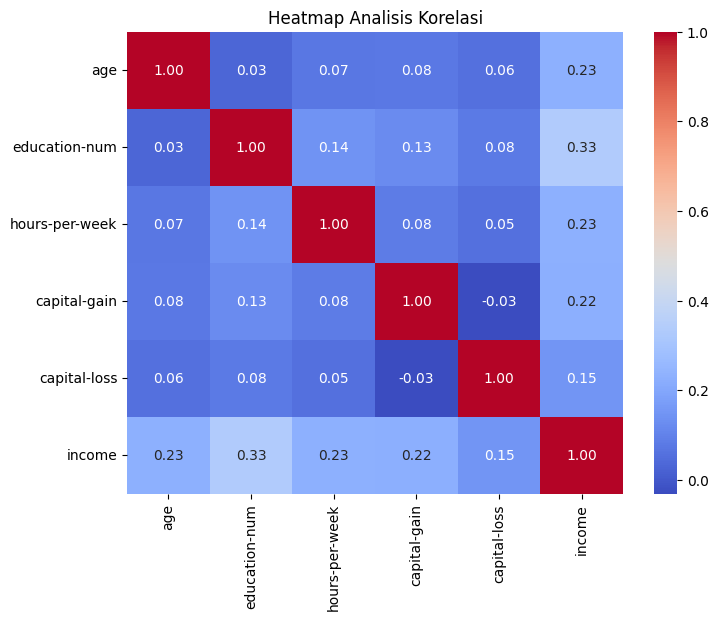

In [24]:

kolom_korelasi = ['age', 'education-num', 'hours-per-week', 'capital-gain', 'capital-loss', 'income']
corr_matrix = df[kolom_korelasi].corr()

# Tampilkan visualisasi korelasi
plt.figure(figsize=(8,6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Heatmap Analisis Korelasi")
plt.show()

In [ ]:
# Hasil analisis jelaskan pada cell ini
'''
Interpretasi Hasil Korelasi:
1. Variabel 'education-num' (tingkat pendidikan) memiliki korelasi positif paling tinggi terhadap 'income', menunjukkan bahwa semakin tinggi pendidikan seseorang, semakin besar peluangnya berpenghasilan >50K.
2. Variabel 'age' dan 'hours-per-week' juga memiliki korelasi positif sedang terhadap 'income'.
3. 'capital-gain' berbanding lurus tipis dengan pendapatan, sedangkan antar variabel prediktor (fitur) tidak terjadi gejala multikolinearitas yang kuat (semua korelasi antar fitur jauh di bawah 0.8).
'''

# Bagian 5 - Pra Pengolahan Data Pada Dataset MNIST

Pada bagian ini, Anda diminta untuk melakukan proses EDA dan pra pengolahan data sederhana pada dataset MNIST. Dataset MNIST merupakan data citra tulisan tangan untuk digil 0 hingga 9. Sebelum melakukan proses pengolahan, Anda akan dibantu dengan proses loading data dan inspeksi data.

Hints:
1. Hanya gunakan data **Test**
2. Anda perlu melakukan pengolahan terhadap semua data test (total 10k data). Anda dapat menggunakan function untuk mempermudah pekerjaan.

In [ ]:
# Fetch data and inspect data shape
from tensorflow.keras.datasets import mnist
import numpy as np
import matplotlib.pyplot as plt

# Load train & test split
(X_train, y_train), (X_test, y_test) = mnist.load_data()

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (60000, 28, 28)
Test shape: (10000, 28, 28)


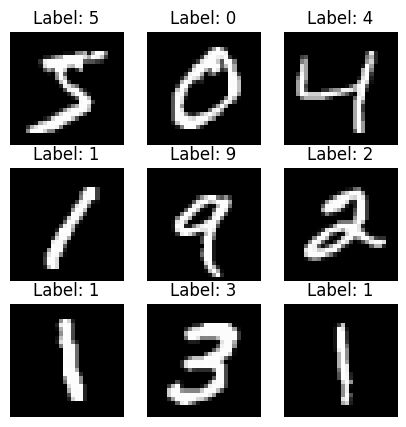

In [ ]:
# Inspeksi Visual
plt.figure(figsize=(5,5))
for i in range(9):
    plt.subplot(3,3,i+1)
    plt.imshow(X_train[i], cmap="gray")
    plt.title(f"Label: {y_train[i]}")
    plt.axis("off")
plt.show()

## Soal 1 (10 poin)
1. Lakukan proses **upsampling** citra menjadi ukuran 32x32
2. Tampilakan 5 data hasil proses **upsampling**

Hint: Anda harus membuat array kosong untuk menampung hasil upsampling. Replace pada array X_test tidak dapat dilakukan karena data disimpan dalam bentuk ndarray yang memiliki ukuran fix (10000, (28,28))

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


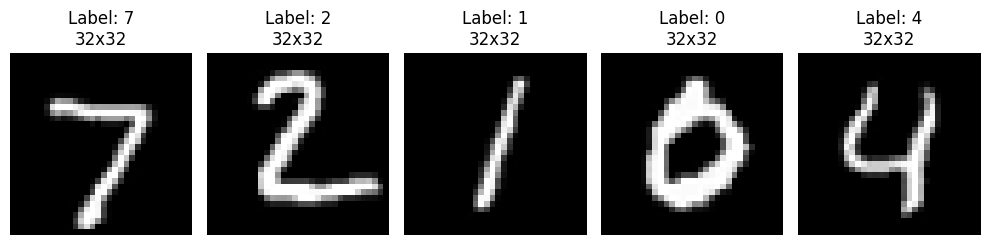

In [27]:
from tensorflow.keras.datasets import mnist

# Mengunduh dan mendefinisikan X_train, y_train, X_test, dan y_test
(X_train, y_train), (X_test, y_test) = mnist.load_data()

# --- JAWABAN SOAL 1 ---
# Membuat array kosong ukuran (10000, 32, 32)
X_test_32 = np.zeros((X_test.shape[0], 32, 32))

# Proses Upsampling 28x28 -> 32x32
for i in range(len(X_test)):
    X_test_32[i] = cv2.resize(X_test[i], (32, 32), interpolation=cv2.INTER_CUBIC)

# Tampilkan 5 data hasil upsampling
plt.figure(figsize=(10,4))
for i in range(5):
    plt.subplot(1, 5, i+1)
    plt.imshow(X_test_32[i], cmap='gray')
    plt.title(f"Label: {y_test[i]}\n32x32")
    plt.axis("off")
plt.tight_layout()
plt.show()

## Soal 2 (10 poin)
Lakukan normalisasi nilai citra tiap piksel menjadi rentang 0-1

In [28]:
# Maksimal pixel adalah 255
X_test_norm = X_test_32 / 255.0

print(f"Min pixel value: {X_test_norm.min()}")
print(f"Max pixel value: {X_test_norm.max()}")

Min pixel value: 0.0
Max pixel value: 1.0


## Soal 3 (10 poin)
Ubah metriks citra menjadi array 1 dimensi. Lakukan pada semua data test yang sudah di resize dan normalisasi.

Hint: Anda harus membuat holder array kosong untuk menampung hasilnya.

In [29]:
# Mengubah dimensi (10000, 32, 32) menjadi (10000, 1024)
X_test_flat = X_test_norm.reshape(X_test_norm.shape[0], -1)

print("Shape setelah Flattening:", X_test_flat.shape)

Shape setelah Flattening: (10000, 1024)
